# Regression

## 0. Imports

In [97]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [98]:
df = pd.read_csv('/Users/cleganeb/Desktop/DSB10_Intro_to_ML.ID_1577653-1/src/data/checker_regression.csv')

In [99]:
df = df.fillna(0)
display(df)

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,0.00
1,user_1,62,28.0,0.00
2,user_1,62,28.0,0.00
3,user_1,62,28.0,0.00
4,user_1,62,28.0,0.00
...,...,...,...,...
72,user_31,128,0.0,-104.75
73,user_4,40,0.0,-175.60
74,user_6,15,0.0,-62.60
75,user_7,8,0.0,-115.50


In [100]:
X = df.drop(['uid', 'AVG(diff)'], axis=1)
y = df['AVG(diff)'] 
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, random_state=42)

print("Dimensions:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
df.info()

Dimensions:
X_train: (61, 2) X_test: (16, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          77 non-null     object 
 1   num_commits  77 non-null     int64  
 2   pageviews    77 non-null     float64
 3   AVG(diff)    77 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.5+ KB


## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [101]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def crossval(n_splits, X, y, model_factory):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    rmse_train = []
    rmse_test = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        model = model_factory()
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        rmse_train.append(rmse(y_train, y_pred_train))
        rmse_test.append(rmse(y_test, y_pred_test))

        print(f'train - {rmse_train[-1]:.16f}   |   test - {rmse_test[-1]:.16f}')

    avg_rmse = np.mean(rmse_test)
    print(f'Average RMSE on crossval is {avg_rmse:.16f}')
    return rmse_test, avg_rmse  
        

In [102]:
def linear_regression():
    return LinearRegression()

def decision_tree_regressor():
    return DecisionTreeRegressor(max_depth=4, random_state=21)

def random_forest_regressor():
    return RandomForestRegressor(n_estimators=100, max_depth=None, random_state=21)

n_splits = 10

print('== Linear Regression ==')
scores_lr, avg_lr = crossval(n_splits, X, y, linear_regression)

print('\n== Decision Tree Regressor ==')
scores_dtr, avg_dtr = crossval(n_splits, X, y, decision_tree_regressor)

print('\n== Random Forest Regressor ==')
scores_rfc, avg_rfc = crossval(n_splits, X, y, random_forest_regressor)

== Linear Regression ==
train - 42.2729101523379711   |   test - 70.4397939728024198
train - 47.4572664823796870   |   test - 30.6573940143540433
train - 47.7785438860429892   |   test - 27.1373193782691082
train - 46.2441901620785032   |   test - 44.1230720520963686
train - 46.3935500474224440   |   test - 42.4203917281636649
train - 47.7154191480249708   |   test - 28.2733916545140538
train - 46.3089186604565057   |   test - 45.6731372740056116
train - 47.8119464724218091   |   test - 20.5724765809234214
train - 44.1291532453289719   |   test - 63.1495771894194604
train - 42.3508931413688856   |   test - 74.1589333008101192
Average RMSE on crossval is 44.6605487145358282

== Decision Tree Regressor ==
train - 17.3745133390295550   |   test - 72.6072607542531614
train - 18.7258698370476928   |   test - 5.9662134662614950
train - 18.8200866718029971   |   test - 0.0000000000000000
train - 17.5295950416272177   |   test - 34.7896536343781406
train - 17.1120891479693817   |   test - 65.3

## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [112]:
lr = LinearRegression().fit(X_train, y_train)
dtr = DecisionTreeRegressor(max_depth=4, random_state=21).fit(X_train, y_train)
rfc = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=21).fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_dtr = dtr.predict(X_test)
y_pred_rfc = rfc.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_dtr = np.sqrt(mean_squared_error(y_test, y_pred_dtr))
rmse_rfc = np.sqrt(mean_squared_error(y_test, y_pred_rfc))
print(f"RMSE Linear Regression: {rmse_lr:.4f}")
print(f"RMSE Decision Tree Regressor: {rmse_dtr:.4f}")
print(f"RMSE Random Forest Regressor: {rmse_rfc:.4f}")

RMSE Linear Regression: 52.8290
RMSE Decision Tree Regressor: 54.4356
RMSE Random Forest Regressor: 43.9993


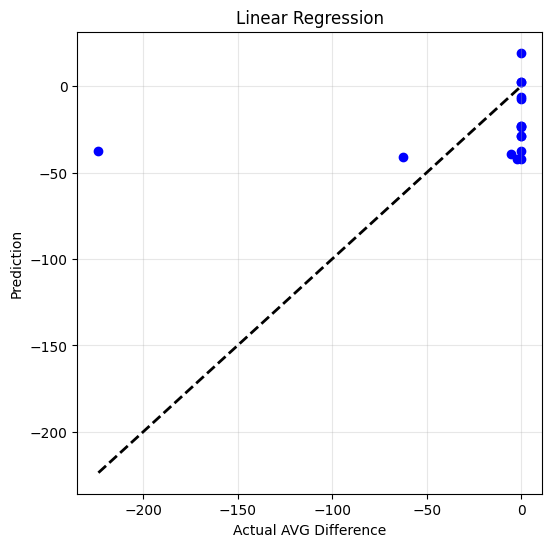

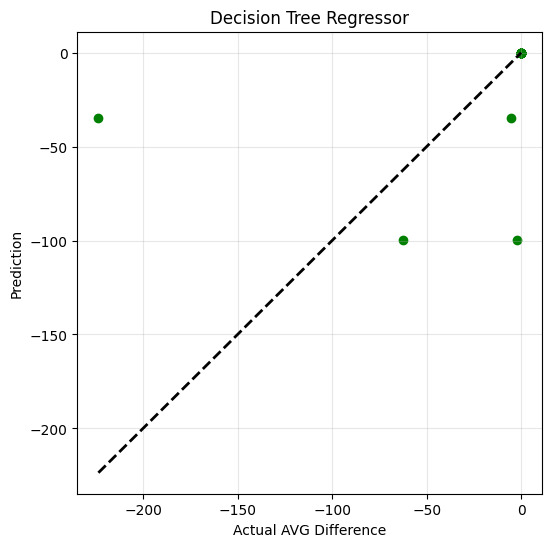

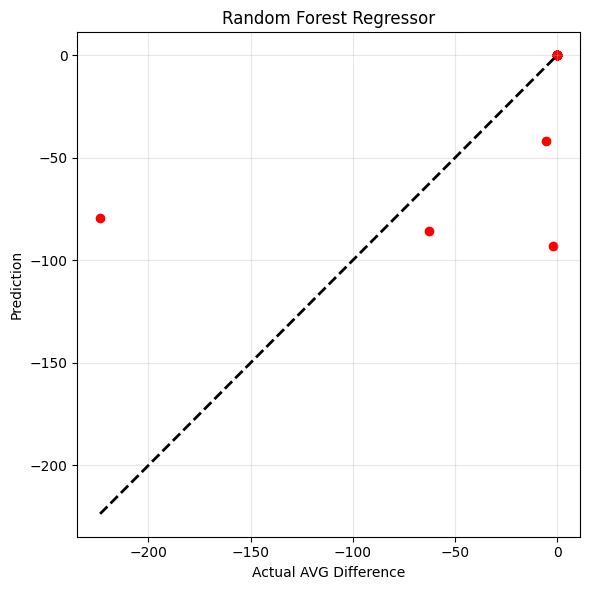

In [117]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, color='blue')
plt.title('Linear Regression')
plt.xlabel('Actual AVG Difference')
plt.ylabel('Prediction')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', lw=2, color='black')  # Диагональ y=x
plt.grid(True, alpha=0.3)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_dtr, color='green')
plt.title('Decision Tree Regressor')
plt.xlabel('Actual AVG Difference')
plt.ylabel('Prediction')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', lw=2, color='black')
plt.grid(True, alpha=0.3)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rfc, color='red')
plt.title('Random Forest Regressor')
plt.xlabel('Actual AVG Difference')
plt.ylabel('Prediction')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', lw=2, color='black')
plt.grid(True, alpha=0.3)

plt.tight_layout()  
plt.show()


Ideally, the points representing the model's predictions should be located as close as possible to the straight line y=x. That is, each point should lie on or near the line itself. Such a graph demonstrates a high degree of correspondence between the predicted value and the actual value.